<a href="https://colab.research.google.com/github/Spicyredd/Learn_PyTorch/blob/master/02_pytorch_classification_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02. Neural Network classification with PyTorch

Classification is a problem of predicting whether something is one thing or another (there can be multiple things as the option).

Book version of this notebook - https://www.learnpytorch.io/02_pytorch_classification/

All other resources - https://github.com/mrdbourke/pytorch-deep-learning/tree/main

Ask a quesion here - https://github.com/mrdbourke/pytorch-deep-learning/discussions

## 1. Make classification data and get it ready

In [ ]:
import sklearn
from sklearn.datasets import make_circles

# Make a thousand samples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

In [ ]:
len(X), len(y)

(1000, 1000)

In [ ]:
print(f"First 5 samples of X: {X[:5]}")
print(f"First 5 samples of y: {y[:5]}")

First 5 samples of X: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y: [1 1 1 1 0]


In [ ]:
# Make DataFrame of circle data
import pandas as pd
circles = pd.DataFrame({'X1': X[:, 0],
                       'X2':X[:, 1],
                       'label':y})
circles.head()

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


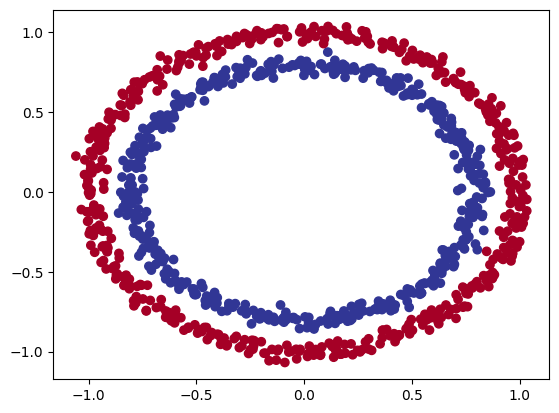

In [ ]:
# Visualize
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu)

**Note:** The data we're working with is often referred to as a toy dataset, a dataset that is small enough to experiment but still sizeable enough to practice the fundamentals.

### 1.1 Check input and output shapes

In [ ]:
X.shape, y.shape

((1000, 2), (1000,))

In [ ]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [ ]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]

print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shape for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shape for one sample of X: (2,) and the same for y: ()


### 1.2 Turn data into tensors and create trains and test splits

In [ ]:
import torch
torch.__version__

'2.6.0+cu124'

In [ ]:
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [ ]:
type(X), X.dtype, y.dtype

(torch.Tensor, torch.float32, torch.float32)

In [ ]:
# Split data into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    train_size=0.8,
                                                    random_state=42)

In [ ]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [ ]:
n_samples

1000

## 2. Building a model

Let's build a model to classify our blue and red dots.

To do so, we want to:
1. Setup device agnostic code so our code will run on an accelerator (GPU) if there is one
2. Construct a model (by subclassing `nn.Module`)
3. Define a loss function and optimizer
4. Setup a training and test loop

In [ ]:
# Import PyTorch and nn
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
X_train

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

Now we've setup device agnostic code, let's create a model that:

1. Subclasses `nn.Module` (almost all models in PyTorch subclass `nn.Module`)
2. Create 2 `nn.Linear()` layers that are capable of handling the shapes of our data
3. Defines a `forward()` method that outlines the forward pass (or forward computation) of the model
4. Instantiate an instance of our model class and send it to the target device

In [ ]:
# 1. Construct.a model that subclasses nn.Module
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    # 2. Create 2 nn.Linear layers capable of handling the shapes of our data
    self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features and upscales to 5 features
    self.layer_2 = nn.Linear(in_features=5, out_features=1) # takes in 5 features from previous layer and downscales to 1

  # 3. Define a forward() method that outlines the forward pass
  def forward(self, x):
    return self.layer_2(self.layer_1(x)) # x -> layer_1 -> layer_2

  # 4. Instantiate an instance of our model class and send it to the target device
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
next(model_0.parameters()).device

device(type='cpu')

In [ ]:
model_0 = nn.Sequential(
        nn.Linear(in_features=2, out_features=5),
        nn.Linear(in_features=5, out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.3030,  0.0322],
                      [ 0.0977,  0.4447],
                      [-0.3172, -0.0892],
                      [-0.3377,  0.6720],
                      [ 0.0190,  0.6104]])),
             ('0.bias', tensor([ 0.2085, -0.6441, -0.0338,  0.3589,  0.2710])),
             ('1.weight',
              tensor([[-0.2481,  0.1341,  0.4388,  0.0622, -0.2976]])),
             ('1.bias', tensor([-0.2268]))])

In [ ]:
# Make predictions
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
print(f'Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}')
print(f'Length of test samples: {len(X_test)}, Shape: {X_test.shape}')
print(f'\nFirst 10 predictions:\n{untrained_preds[:10]}')
print(f'\nFirst 10 labels:\n{y_test[:10]}')

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First 10 predictions:
tensor([[-0.4959],
        [-0.5616],
        [-0.3435],
        [-0.5391],
        [-0.3746],
        [-0.4144],
        [-0.5745],
        [-0.5401],
        [-0.3424],
        [-0.5663]])

First 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [ ]:
X_test[:10], y_test[:10]

(tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

### 2.1 Setup loss function and optimizer

Which loss function or optimizer should you use?

Again... this is problem specfic.

For example for regression you might want MAE or MSE

For Classification you might want binary cross entropy or categorical cross entropy (cross entropy).


As a reminder, the loss function measures how *wrong* your model's predictions are

And for optimizers, two of the most common and useful are SGD and Adam, however PyTorch has many build-in options.

* For the loss function we're going to user `torch.nn.BCEWithLogitsLoss()`, for more on what binary cross entropy (BCE) is, check out this article - https://towardsdatascience.com/
understanding-binary-cross-entropy-log-loss-a-visual-explanation-a3ac6025181a

* For a definition on what a logit is in deep learning - https://stackoverflow.com/a/52111173/7900723
* For different optimizers see torch.optim



In [ ]:
# Setup the loss function
# loss_fn = nn.BCELoss() # BCELoss = reqires inputs to have gone through the sigmoid activation function prior to input to BCELoss
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid activation function built-in

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

In [14]:
# Calculate accuracy - out of 100 example, what percentage does our model get right?
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = correct/(len(y_pred))*100
  return acc

## 3. Train model

To train our model, we're going to need a training loop

1. Forward pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward (backpropagation)
5. Optimizer step (gradient descent)

### 3.1 Going from raw logits -> prediction probabilities -> prediction labels

Our model outputs are going to be raw **logits**

We can convert these **logits** into prediction probabilities by pass them to some kind of activation function (e.g. sigmoid for binary classification and softmax for multiclass classification).

Then we can convert our models' prediction probabilities to **prediction labels** by either rounding them or taking the `argmax()`.

In [ ]:
# View the first 5 outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.4959],
        [-0.5616],
        [-0.3435],
        [-0.5391],
        [-0.3746]])

In [ ]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [ ]:
# Use the sigmoid activation function on our model logits to turn them into prediction probabilities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.3785],
        [0.3632],
        [0.4150],
        [0.3684],
        [0.4074]])

For our prediction probability values, we need to perform a range-style rounding on them:
* `y_pred_probs` >=0.5, `y=1` (class 1)
* `y_pred_probs` < 0.5 `y=0` (class 0)

In [ ]:
# Find the predicted labels
y_preds = torch.round(y_pred_probs)

# In full (logits -> pred probs -> pred labels)
model_0.eval()
with torch.inference_mode():
  y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()


tensor([True, True, True, True, True])


tensor([0., 0., 0., 0., 0.])

### 3.2 Building a training and test loop

In [ ]:
torch.manual_seed(42)

epochs = 100
model_0 = CircleModelV0()
model_0.to(device)
for epoch in range(epochs):
  model_0.train()

  # Forward pass
  y_logits = model_0(X_train.to(device)).squeeze()
  y_preds = torch.sigmoid(y_logits)
  y_preds = torch.round(y_preds)

  # Loss calculation'
  # loss = loss_fn(torch.sigmoid(y_logits), # nn.BCELoss expects prediction probabilities
  #                y_train)
  loss = loss_fn(y_logits, y_train.squeeze()) ##nn.BCEWithLogitsLoss expects raw logits as input
  accuracy = accuracy_fn(y_true=y_train,
                         y_pred=y_preds)

  # Optimizer zero
  optimizer.zero_grad()

  # Loss backward
  loss.backward()

  # Optimizer step
  optimizer.step()

  ### Testing
  model_0.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = model_0(X_test.to(device)).squeeze()
    test_preds = torch.sigmoid(test_logits)
    test_preds = torch.round(test_preds)

    # 2. Calculate the test loss/acc
    test_loss = loss_fn(test_logits, y_test.squeeze())
    test_accuracy = accuracy_fn(y_true=y_test,
                                y_pred=test_preds)

  if epoch % 10 == 0:
    print(f'Epoch: {epoch} | Loss: {loss} | Accuracy: {accuracy} | Test Loss: {test_loss} | Test Accuracy: {test_accuracy}')

Epoch: 0 | Loss: 0.6956854462623596 | Accuracy: 50.0 | Test Loss: 0.6974053382873535 | Test Accuracy: 50.0
Epoch: 10 | Loss: 0.6956854462623596 | Accuracy: 50.0 | Test Loss: 0.6974053382873535 | Test Accuracy: 50.0
Epoch: 20 | Loss: 0.6956854462623596 | Accuracy: 50.0 | Test Loss: 0.6974053382873535 | Test Accuracy: 50.0
Epoch: 30 | Loss: 0.6956854462623596 | Accuracy: 50.0 | Test Loss: 0.6974053382873535 | Test Accuracy: 50.0
Epoch: 40 | Loss: 0.6956854462623596 | Accuracy: 50.0 | Test Loss: 0.6974053382873535 | Test Accuracy: 50.0
Epoch: 50 | Loss: 0.6956854462623596 | Accuracy: 50.0 | Test Loss: 0.6974053382873535 | Test Accuracy: 50.0
Epoch: 60 | Loss: 0.6956854462623596 | Accuracy: 50.0 | Test Loss: 0.6974053382873535 | Test Accuracy: 50.0
Epoch: 70 | Loss: 0.6956854462623596 | Accuracy: 50.0 | Test Loss: 0.6974053382873535 | Test Accuracy: 50.0
Epoch: 80 | Loss: 0.6956854462623596 | Accuracy: 50.0 | Test Loss: 0.6974053382873535 | Test Accuracy: 50.0
Epoch: 90 | Loss: 0.695685446

## 4. Make predictions and evaluate the model

From the metrics it looks like our model isn't learning anything...

So to inspect it let's make some predictions and make them visual!

In other words, "Visualize, visualize, visualize"

To do so, we're going to import a function called `plot_descision_boundary`

In [41]:
import requests
from pathlib import Path

FILE_NAME = "helper_functions.py"
# Download helper function from Learn PyTorch repo (if it's not already downloaded)
if Path(FILE_NAME).is_file():
  print(f"{FILE_NAME} already exists, skipping download")
else:
  print(f"Downloading {FILE_NAME}")
  request = requests.get("http://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open(FILE_NAME, "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

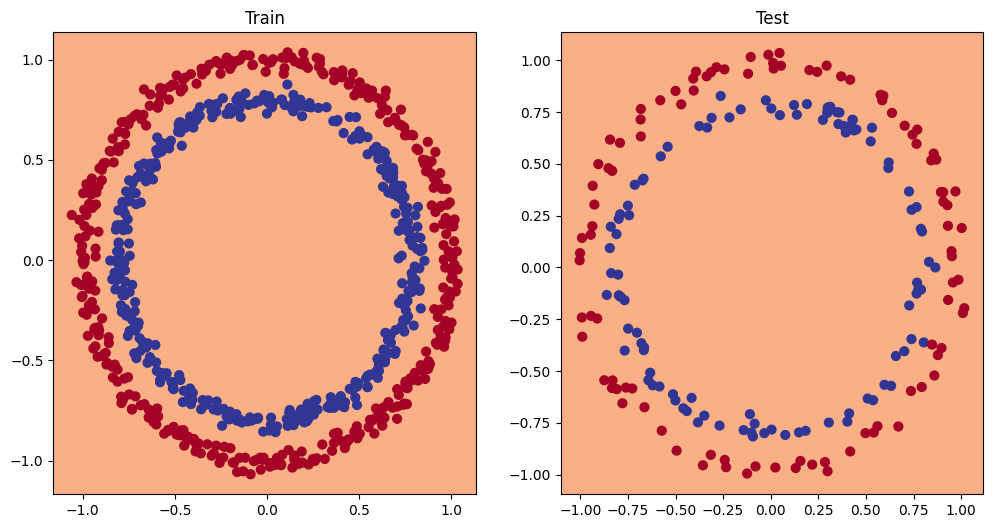

In [ ]:
# Plot decision boundary of the model
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

## 5. Improving a model (from a model perspective)

* Add more layers - give the model more chances to learn about patterns in the data
* Add more hidden units - go from 5 hidden units to 10 hidden units
* Fit for longer
* Changing the activation functions
* Change the learning rate
* Change the loss function

These options are all from a model's perspective because they deal directly with the model, rathen than the data.

And because these options are all values we (as machine learning engineers and data scientists) can change, they are referred as **hyperparameters**.

Let's try and improve our model by:
* Adding more hidden units: 5 -> 10
* Increase the number of layers: 2->3
* Increase the number of epochs: 100 -> 1000

In [ ]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x):
    # z = self.layer_1(x)
    # z = self.layer_2(z)
    # z = self.layer_3(z)
    return self.layer_3(self.layer_2(self.layer_1(x))) # this way of writing operations leverages speed ups where possible behind the scenes

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
model_1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386],
                      [-0.6007,  0.5459],
                      [ 0.1177, -0.2296],
                      [ 0.4370,  0.1102],
                      [ 0.5713,  0.0773],
                      [-0.2230,  0.1900]])),
             ('layer_1.bias',
              tensor([-0.1918,  0.2976,  0.6313,  0.4087, -0.3091,  0.4082,  0.1265,  0.3591,
                      -0.4310, -0.7000])),
             ('layer_2.weight',
              tensor([[-0.1222, -0.2426,  0.2595,  0.0911,  0.1310,  0.1000, -0.0055,  0.2475,
                       -0.2247,  0.0199],
                      [-0.2158,  0.0975, -0.1089,  0.0969, -0.0659,  0.2623, -0.1874, -0.1886,
                       -0.1886,  0.2844],
                      [ 0.1054,  0.3043, -0.2610, -0.3137, -0.2474, -0.2

In [ ]:
# Create a loss function
loss_fn = nn.BCEWithLogitsLoss()

# Create an optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

In [ ]:
# Write a training and evaluation loop for model_1
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Train for longer
epochs = 1000

# Put data on the target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_train = X_test.to(device), y_train.to(device)

for epoch in range(epochs):
  ### Training
  model_1.train()

  # 1. Forward pass
  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> prediction probabilites -> predictions

  # 2. Calculate the loss/acc
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_true=y_train,
                    y_pred=y_pred)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward (backpropagation)
  loss.backward()

  # 5. Optimizer step (gradiend descent)
  optimizer.step()

  ### Testing
  model_1.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits)) # logits -> prediction proabilities -> predictions

    # 2. Calculate loss
    test_loss = loss_fn(test_logits,
                        y_test)

    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_pred)

    # Print out what's happening
    if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.70021, Acc: 51.50% | Test Loss: 0.70111, Test acc: 53.00%
Epoch: 100 | Loss: 0.69308, Acc: 50.25% | Test Loss: 0.69443, Test acc: 48.50%
Epoch: 200 | Loss: 0.69299, Acc: 51.00% | Test Loss: 0.69440, Test acc: 47.00%
Epoch: 300 | Loss: 0.69298, Acc: 51.50% | Test Loss: 0.69446, Test acc: 46.00%
Epoch: 400 | Loss: 0.69298, Acc: 51.50% | Test Loss: 0.69451, Test acc: 45.00%
Epoch: 500 | Loss: 0.69298, Acc: 51.38% | Test Loss: 0.69455, Test acc: 45.00%
Epoch: 600 | Loss: 0.69298, Acc: 51.25% | Test Loss: 0.69458, Test acc: 45.00%
Epoch: 700 | Loss: 0.69298, Acc: 51.12% | Test Loss: 0.69460, Test acc: 45.50%
Epoch: 800 | Loss: 0.69298, Acc: 51.12% | Test Loss: 0.69462, Test acc: 45.50%
Epoch: 900 | Loss: 0.69298, Acc: 51.12% | Test Loss: 0.69464, Test acc: 45.50%


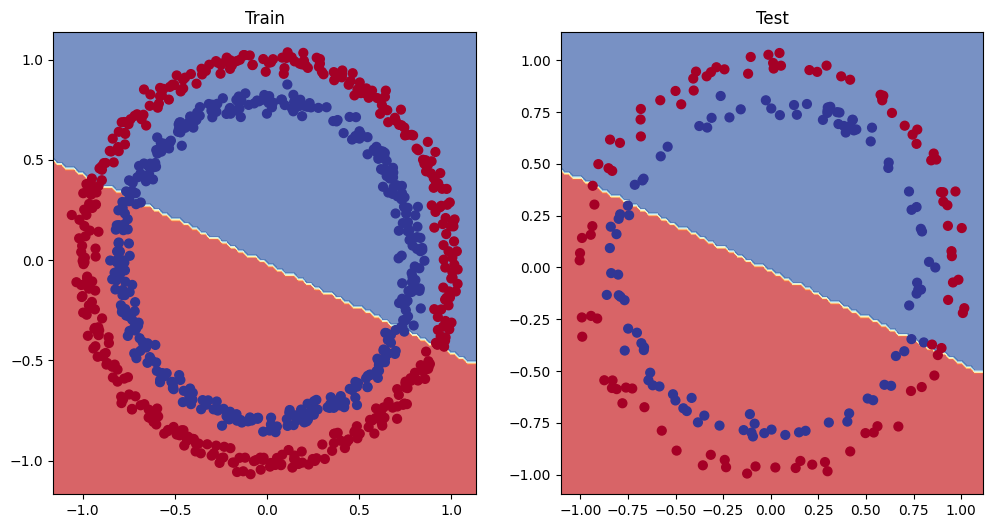

In [ ]:
# Plot the decision boundary
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

### 5.1 Preparing data to see if our model can fit a straight line

One way to troubleshoot to a larger problem is to test out a smaller problem.

In [ ]:
# Create some data (same as notebook 01)

weight = 0.7
bias = 0.3

start = 0
end = 1
steps = 0.01

# Create data
X_line = torch.arange(start, end, steps).unsqueeze(dim=1)
y_line = weight * X_line * bias # Linear regression formula (without epsilon)


# Check the data
print(len(X_line))
X_line[:10], y_line[:10]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400],
         [0.0500],
         [0.0600],
         [0.0700],
         [0.0800],
         [0.0900]]),
 tensor([[0.0000],
         [0.0021],
         [0.0042],
         [0.0063],
         [0.0084],
         [0.0105],
         [0.0126],
         [0.0147],
         [0.0168],
         [0.0189]]))

In [ ]:
# Create train and test split
train_split = int(0.8 * len(X_line))
X_train_line, y_train_line = X_line[:train_split], y_line[:train_split]
X_test_line, y_test_line = X_line[train_split:], y_line[train_split:]

# Check the len of each
len(X_train_line), len(y_train_line), len(X_test_line), len(y_test_line)

(80, 80, 20, 20)

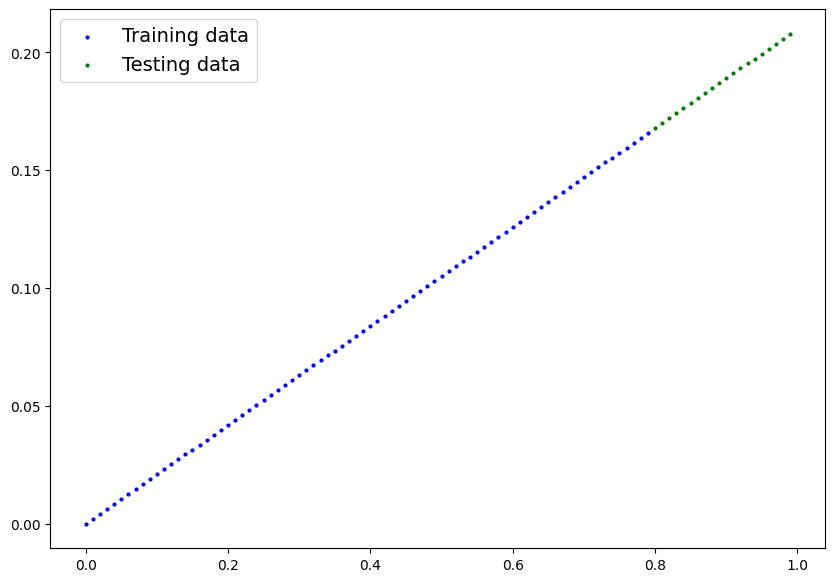

In [ ]:
plot_predictions(train_data=X_train_line,
                 train_labels=y_train_line,
                 test_data=X_test_line,
                 test_labels=y_test_line)

### 5.2 Adjust `model_1` to fit a straight line

In [ ]:
# Same architecture as model_1 (but using nn.Sequential())

model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
# Loss and optimizer
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.01)

In [ ]:
# Train the model
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put the data on the target device
X_train_line, y_train_line = X_train_line.to(device), y_train_line.to(device)
X_test_line, y_test_line = X_test_line.to(device), y_test_line.to(device)

# Setup training loop
for epoch in range(epochs):
  y_pred = model_2(X_train_line)
  loss = loss_fn(y_pred, y_train_line)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # Testing
  model_2.eval()
  with torch.inference_mode():
    test_pred = model_2(X_test_line)
    test_loss = loss_fn(test_pred, y_test_line)

  # Print out what's happening
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test loss: {test_loss:.5f}")

Epoch: 0 | Loss: 0.26631 | Test loss: 0.17248
Epoch: 100 | Loss: 0.01736 | Test loss: 0.01467
Epoch: 200 | Loss: 0.02338 | Test loss: 0.00951
Epoch: 300 | Loss: 0.02638 | Test loss: 0.00729
Epoch: 400 | Loss: 0.02465 | Test loss: 0.00959
Epoch: 500 | Loss: 0.02362 | Test loss: 0.01121
Epoch: 600 | Loss: 0.02138 | Test loss: 0.01395
Epoch: 700 | Loss: 0.01982 | Test loss: 0.01604
Epoch: 800 | Loss: 0.01830 | Test loss: 0.01809
Epoch: 900 | Loss: 0.01682 | Test loss: 0.02009


In [ ]:
# Turn on evaluation mode
model_2.eval()

# Make preditions (inference)
with torch.inference_mode():
  y_pred = model_2(X_test_line)

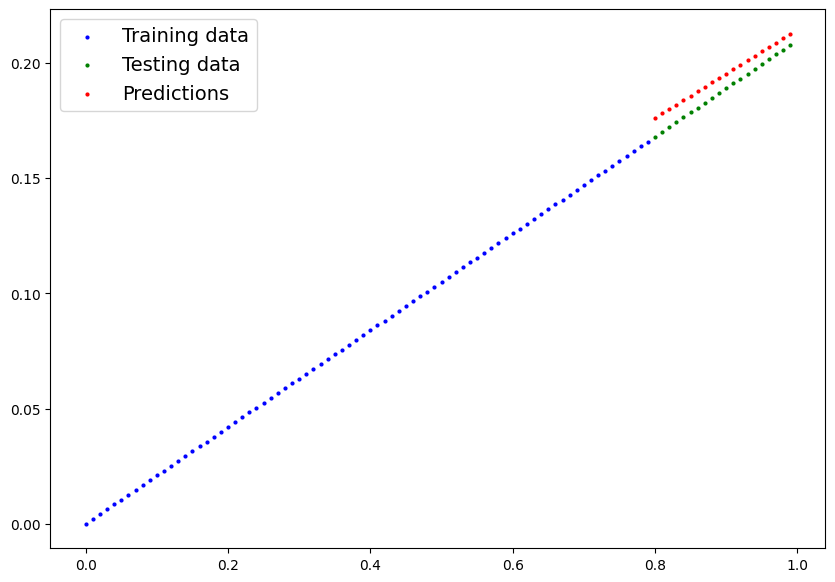

In [ ]:
# Plot data and predictions
plot_predictions(train_data=X_train_line,
                 train_labels=y_train_line,
                 test_data=X_test_line,
                 test_labels=y_test_line,
                 predictions=y_pred)

## 6. The missing piece: non-linearity

"What patterns could you draw if you were given an infinite anount of a straight and non-straight lines?"

Or in machine learning terms, an infinite (but really it is finite) of linear and non-linear functions?

### 6.1 Recreating non-linear data(red and blue circles)

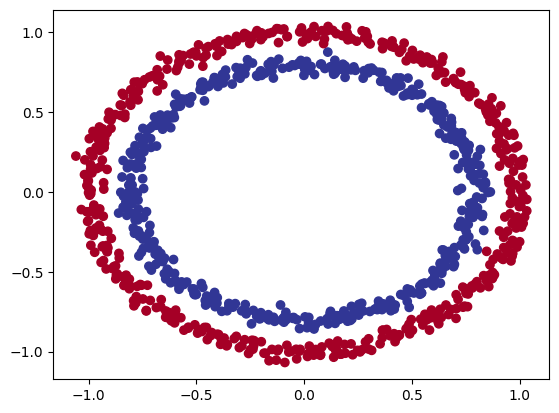

In [ ]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

plt.scatter(X[:, 0],
            X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu)

In [ ]:
# Convert data to tensors then to train and test splits
import torch
from sklearn.model_selection import train_test_split

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

### 6.2 Building a model with non-linearity

* Linear = straight linear
* Non-linear = non-straight lines

In [ ]:
# Build a model with non-linear activation function
from torch import nn

class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU() # RelU is a non-linear activation function

  def forward(self, x):
    # Where should we put our non-linear activation function?
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [ ]:
# Setting up optimizer and loss function
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_3.parameters(),
                            lr=0.1)

### 6.3 Training a model with non-linearity

In [ ]:
# Random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Loop through the data
epochs = 1500

for epoch in range(epochs):
  model_3.train()
  y_logit = model_3(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logit))
  loss = loss_fn(y_logit, y_train)
  accuracy = accuracy_fn(y_pred=y_pred,
                         y_true=y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # Testing
  model_3.eval()
  with torch.inference_mode():
    test_logit = model_3(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logit))
    test_loss = loss_fn(test_logit,
                        y_test)
    test_accuracy = accuracy_fn(y_true=y_test,
                                y_pred=test_pred)

  # Print out what's happening
  if epoch % 100 == 0:
    print(f'Epoch: {epoch} | Loss: {loss:.4f} | Accuracy: {accuracy:.2f} | Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}')

Epoch: 0 | Loss: 0.6929 | Accuracy: 50.00 | Test Loss: 0.6932 | Test Accuracy: 50.00
Epoch: 100 | Loss: 0.6912 | Accuracy: 52.88 | Test Loss: 0.6910 | Test Accuracy: 52.50
Epoch: 200 | Loss: 0.6898 | Accuracy: 53.37 | Test Loss: 0.6894 | Test Accuracy: 55.00
Epoch: 300 | Loss: 0.6879 | Accuracy: 53.00 | Test Loss: 0.6872 | Test Accuracy: 56.00
Epoch: 400 | Loss: 0.6852 | Accuracy: 52.75 | Test Loss: 0.6841 | Test Accuracy: 56.50
Epoch: 500 | Loss: 0.6810 | Accuracy: 52.75 | Test Loss: 0.6794 | Test Accuracy: 56.50
Epoch: 600 | Loss: 0.6751 | Accuracy: 54.50 | Test Loss: 0.6729 | Test Accuracy: 56.00
Epoch: 700 | Loss: 0.6666 | Accuracy: 58.38 | Test Loss: 0.6632 | Test Accuracy: 59.00
Epoch: 800 | Loss: 0.6516 | Accuracy: 64.00 | Test Loss: 0.6476 | Test Accuracy: 67.50
Epoch: 900 | Loss: 0.6236 | Accuracy: 74.00 | Test Loss: 0.6215 | Test Accuracy: 79.00
Epoch: 1000 | Loss: 0.5682 | Accuracy: 87.75 | Test Loss: 0.5738 | Test Accuracy: 86.50
Epoch: 1100 | Loss: 0.4815 | Accuracy: 93.50

### 6.4 Evaluating a model trained with non-linear activation functions

In [ ]:
model_3.eval()
with torch.inference_mode():
  y_pred = torch.round(torch.sigmoid(model_3(X_test).squeeze()))
y_pred[:10], y_test[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

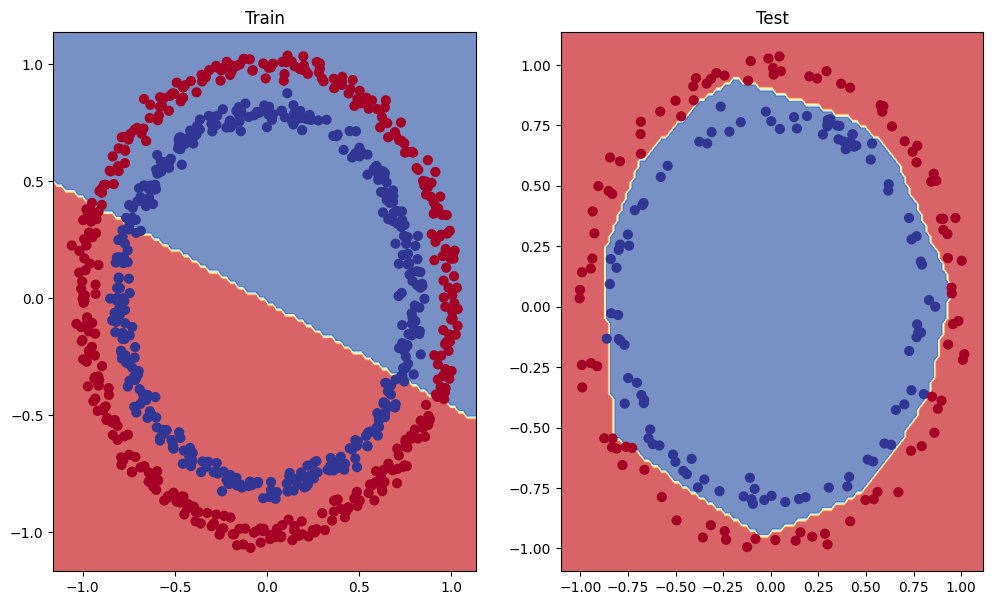

In [ ]:
# Plot decision boundary
plt.figure(figsize=(12,7))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train) # model_1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test) # model_3 = non-linearity

**Challenge:** Can you improve model_3 to do better than 80% accuracy on the test data?

## 7. Replicating non-linear activation functions

Neural networks, rather than us telling the model whats to learn, we give it the tools to discover patterns in data and it tries to figure out the patterns on its own.

And these tools are linear & non-linear functions

In [ ]:
# Create a tensor
A = torch.arange(-10, 10, 1, dtype=torch.float32)
A.dtype

torch.float32

In [ ]:
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

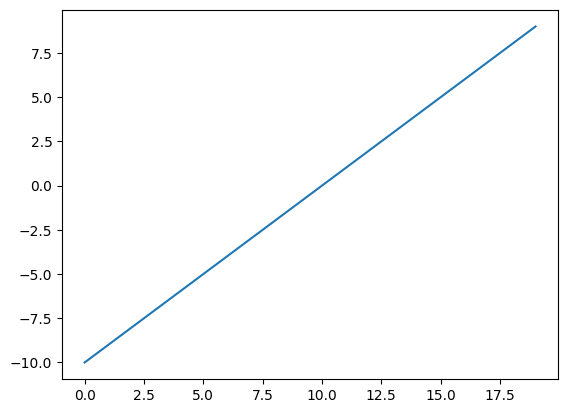

In [ ]:
# Visualize the tensor
plt.plot(A)

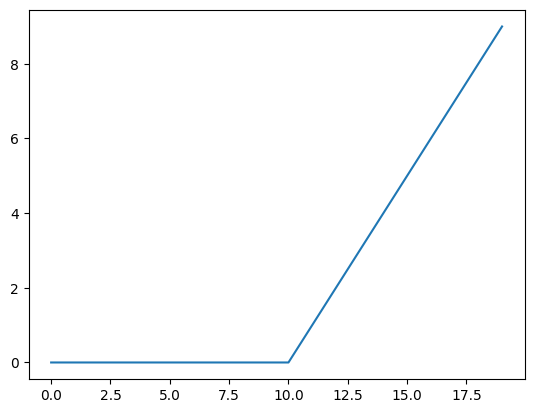

In [ ]:
plt.plot(torch.relu(A))

In [ ]:
def relu(x: torch.Tensor) -> torch.Tensor:
  return torch.maximum(torch.tensor(0), x) # inputs must be tensors

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

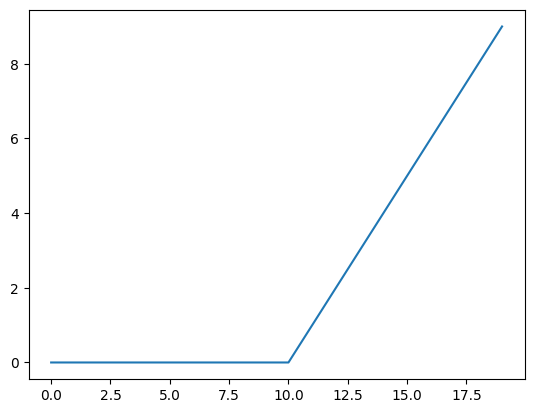

In [ ]:
# Plot ReLU activation function
plt.plot(relu(A))

In [ ]:
# Now let's do the same for Sigmoid
def sigmoid(x):
  return 1 / (1 + torch.exp(-x))

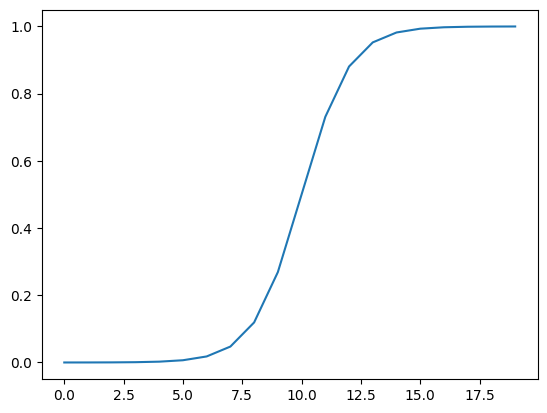

In [ ]:
plt.plot(torch.sigmoid(A))

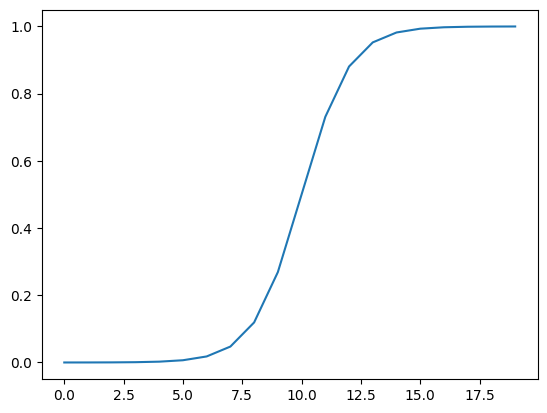

In [ ]:
plt.plot(sigmoid(A))

## 8. Putting it all together with a multi-class classification problem

* Binary classification = one or another(cat vs dog, spam vs not spam, fraud of not fraud)

* Multi-class classification = more than one thing or another (cat vs dog vs chicken)

### 8.1 Creating a toy multi-class dataset

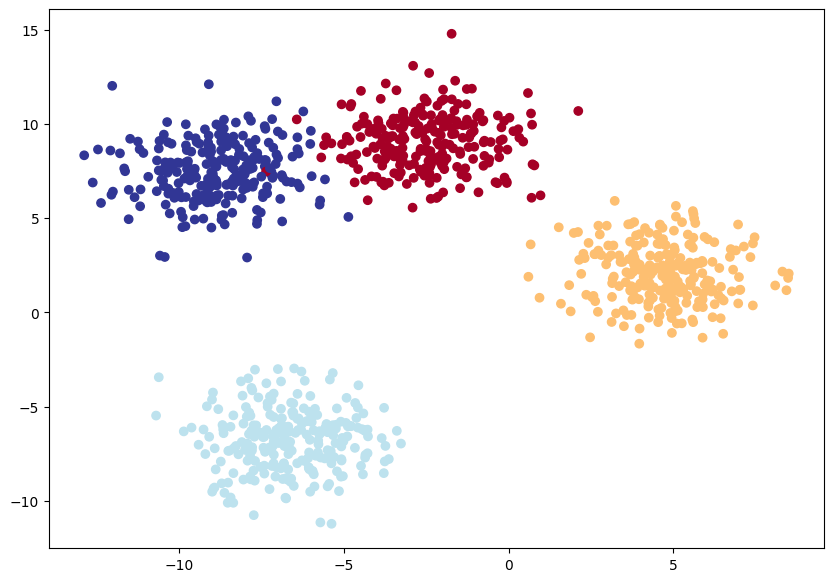

In [1]:
# import dependencies
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs # https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html
from sklearn.model_selection import train_test_split

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create multi-class data
X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES,
                            cluster_std=1.5, # give the clusters a little shake up
                            random_state=RANDOM_SEED)

# 2. Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.long)

# 3. Split into training and test
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size=0.2,
                                                                        random_state=RANDOM_SEED)
# 4. Plot data (visualize, visualize, visualize)
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)

### 8.2 Building a multi-class classification model in PyTorch



In [2]:
# import required libraries

import torch
import torch.nn as nn

In [3]:
# Create device agnostic code

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Using device: {device}')

Using device: cpu


In [70]:
# Build a multi-class classification model
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    """Initializes multi-class classification model.

    Args:
        input_features (int): Number of input features to the model
        ouput_featurs (int): Number of output features (number of output classes)
        hidden_units(int): Number of hidden units between layers, default 8

    Returns:
        None
    Errors:
    """
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features= output_features)
    )

  def forward(self, x:torch.Tensor) -> torch.Tensor:
    return self.linear_layer_stack(x)

# Create an instance of BlobModel and send it to the target device
model_4 = BlobModel(input_features=2,
                    output_features=4,
                    hidden_units=8).to(device)

model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [71]:
X_blob_train.shape, y_blob_train[:5]

(torch.Size([800, 2]), tensor([1, 0, 2, 2, 0]))

In [72]:
torch.unique(y_blob_train)

tensor([0, 1, 2, 3])

### 8.4 Getting prediction proabilities for multi-class model

In order to evaluate and train and test our model, we need to convert our model's outputs (logits) to predictions probabilities and then to prediction labels.

Logits (raw output of the model) -> Predictions (use `torch.softmax`) -> Pred labels (take the argmax of the prediction probabilities)

In [73]:
# Let's get some raw outputs of our model (logits)
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_blob_test)
y_logits[:10]

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834],
        [-0.1497, -1.0617, -0.7107, -0.1645],
        [ 0.1539, -0.2887,  0.1520, -0.0109],
        [-0.2154, -1.1795, -0.9300, -0.2745],
        [ 0.2443, -0.2472,  0.1649,  0.0061],
        [-0.2329, -1.2120, -0.9849, -0.3004]])

In [74]:
# Convert our model's logit outputs to prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834]])
tensor([[0.3169, 0.3244, 0.1405, 0.2182],
        [0.3336, 0.1432, 0.2026, 0.3206],
        [0.3011, 0.1843, 0.2823, 0.2323],
        [0.3078, 0.2766, 0.1836, 0.2320],
        [0.3719, 0.1286, 0.1532, 0.3463]])


In [75]:
# Convert our model's prediction probabilities to prediction labels
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds,y_blob_test

(tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 3, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
         1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 1, 0, 1, 0, 0, 0,
         0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
         1, 0, 0, 0, 0, 1, 0, 1]),
 tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
         2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
         0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
         3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3,

In [76]:
torch.sum(y_pred_probs[0])

tensor(1.0000)

In [77]:
torch.argmax(y_pred_probs[0])

tensor(1)

In [78]:
# Setup loss function for multi-class classification
loss_fn = nn.CrossEntropyLoss()

# Setup optimizer for multi-class classification
optimizer = torch.optim.SGD(params=model_4.parameters(),
                            lr=0.1)

### 8.5 Creating a training and testing loop for multi-class PyTorch model

In [79]:
# Set manual_seed
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set epochs
epochs = 100

# Move data to device
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

# Setup training loop
for epoch in range(epochs):
  # Set model to training mode
  model_4.train()

  # Forward pass
  y_logits = model_4(X_blob_train)
  y_pred = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)

  # Loss calculation
  loss = loss_fn(y_logits, y_blob_train)
  accuracy = accuracy_fn(y_true=y_blob_train,
                         y_pred=y_pred)

  # Optimizer zero grad
  optimizer.zero_grad()

  # Backpropagation
  loss.backward()

  # Optimizer step
  optimizer.step()

  if epoch % 10 == 0:
    ### Testing
    model_4.eval()
    with torch.inference_mode():
      test_logits = model_4(X_blob_test)
      test_preds = torch.argmax(torch.softmax(test_logits, dim=1),dim=1)

      test_loss = loss_fn(test_logits, y_blob_test)
      test_accuracy = accuracy_fn(y_true=y_blob_test,
                                  y_pred=test_preds)

    # Printing out loss and accuracy
    print(f'Epoch: {epoch} | Loss: {loss:.4f} | Accuracy: {accuracy:.2f} | Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}')


Epoch: 0 | Loss: 1.1588 | Accuracy: 40.38 | Test Loss: 1.0755 | Test Accuracy: 48.00
Epoch: 10 | Loss: 0.6448 | Accuracy: 96.75 | Test Loss: 0.6607 | Test Accuracy: 97.50
Epoch: 20 | Loss: 0.4254 | Accuracy: 98.50 | Test Loss: 0.4307 | Test Accuracy: 100.00
Epoch: 30 | Loss: 0.2529 | Accuracy: 99.12 | Test Loss: 0.2451 | Test Accuracy: 99.50
Epoch: 40 | Loss: 0.1123 | Accuracy: 99.25 | Test Loss: 0.1023 | Test Accuracy: 99.50
Epoch: 50 | Loss: 0.0663 | Accuracy: 99.25 | Test Loss: 0.0585 | Test Accuracy: 99.50
Epoch: 60 | Loss: 0.0507 | Accuracy: 99.25 | Test Loss: 0.0429 | Test Accuracy: 99.50
Epoch: 70 | Loss: 0.0430 | Accuracy: 99.25 | Test Loss: 0.0349 | Test Accuracy: 99.50
Epoch: 80 | Loss: 0.0384 | Accuracy: 99.25 | Test Loss: 0.0299 | Test Accuracy: 99.50
Epoch: 90 | Loss: 0.0352 | Accuracy: 99.25 | Test Loss: 0.0266 | Test Accuracy: 99.50


### 8.6 Making and evaluating predictiosn with a PyTorch multi-class model

In [80]:
# Make predictions
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_blob_test)

# View the first 10 predictions
y_logits[:10]

tensor([[-0.6249,  5.9860, -7.6323, -8.4470],
        [-2.1738, -6.3750, -3.7202,  3.1203],
        [-3.4102, -3.8958,  3.1567, -2.6119],
        [-1.1505,  4.1962, -3.8472, -4.8820],
        [ 3.7548, -1.3391, -9.1422, -6.9466],
        [-2.8211, -7.5767, -4.2944,  3.7944],
        [-3.0306, -3.3328,  2.7955, -2.1374],
        [ 3.3761, -4.0375, -6.8987, -3.5503],
        [-4.3620, -4.9904,  3.8123, -3.3814],
        [ 3.5012, -3.0281, -7.5401, -4.7064]])

In [81]:
# Go from logits -> Predictions proabilities
y_pred_probs = torch.softmax(y_logits, dim=1)
y_pred_probs[:10]

tensor([[1.3437e-03, 9.9865e-01, 1.2164e-06, 5.3854e-07],
        [4.9905e-03, 7.4740e-05, 1.0630e-03, 9.9387e-01],
        [1.3985e-03, 8.6060e-04, 9.9463e-01, 3.1073e-03],
        [4.7389e-03, 9.9483e-01, 3.1956e-04, 1.1353e-04],
        [9.9388e-01, 6.0966e-03, 2.4904e-06, 2.2378e-05],
        [1.3372e-03, 1.1504e-05, 3.0644e-04, 9.9834e-01],
        [2.9138e-03, 2.1537e-03, 9.8781e-01, 7.1181e-03],
        [9.9838e-01, 6.0198e-04, 3.4435e-05, 9.7989e-04],
        [2.8147e-04, 1.5016e-04, 9.9882e-01, 7.5044e-04],
        [9.9825e-01, 1.4575e-03, 1.5997e-05, 2.7210e-04]])

In [82]:
# Go from pred probs to pred labels
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

In [83]:
y_blob_test[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

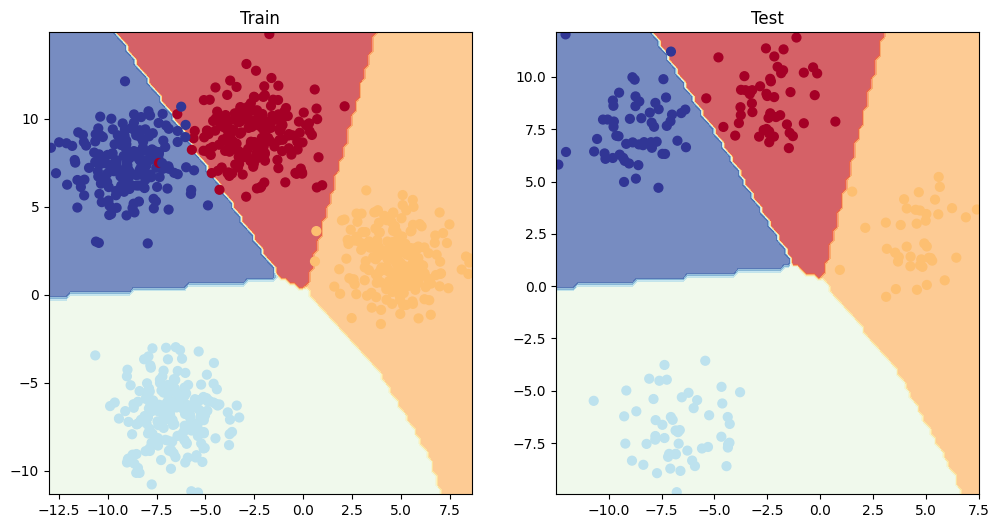

In [84]:
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

## 9. A few more classification metrics... (to evaluate our classification model)

* Accuracy - Out of 100 samples, how many does our model get right?
  * Formula: (TP + TN) / (TP + FP + TN + FN)

* Precision – Out of all the samples the model predicted as positive, how many were actually positive?

  * Formula: TP / (TP + FP)
  * Good when false positives are costly.

* Recall – Out of all the actual positive samples, how many did the model correctly identify?

  * Formula: TP / (TP + FN)
  * Good when false negatives are costly.

* F1-score – The harmonic mean of precision and recall. Balances both.

  * Formula: 2 × (Precision × Recall) / (Precision + Recall)
Useful when classes are imbalanced.

* Confusion matrix – A 2x2 (or more) table showing true positives (TP), false positives (FP), true negatives (TN), and false negatives (FN). Helps you visualize model performance.

* Classification report – A detailed report showing precision, recall, F1-score, and support (number of actual instances) for each class. Summarizes model performance class-wise.

See this article for when to use precision/recall - https://towardsdatascience.com/precision-and-recall-a-comprehensive-guide-with-practical-examples-71d614e3fc43/

If you want access to a lot of PyTorch metrics, see TorchMetrics - https://lightning.ai/docs/torchmetrics/stable/


In [86]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 820.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 79.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [90]:
from torchmetrics import Accuracy

# Setup metric
torchmetric_accuracy = Accuracy(task="multiclass", num_classes=4).to(device)

# Calculate accuracy
torchmetric_accuracy(y_preds, y_blob_test)

tensor(0.9950)